In [1]:
# ===============================================
# 1) Install Libraries
# ===============================================

!pip install -q torch torchvision matplotlib numpy pillow tqdm "albumentations>=2.0.0" opencv-python scikit-learn

In [2]:
# ===============================================
# 2) Import Libraries
# ===============================================

import os
import random
from pathlib import Path
from contextlib import nullcontext

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.datasets import OxfordIIITPet
from sklearn.model_selection import train_test_split

In [3]:
# ===============================================
# 3) Configuration
# ===============================================

SEED = 42

USE_GOOGLE_DRIVE = False
RESUME_TRAINING = False

DATA_DIR = "/content/data"

IMG_SIZE = 320
BATCH_SIZE = 6

EPOCHS = 18
LR = 1e-4
WEIGHT_DECAY = 1e-5
EARLY_STOP_PATIENCE = 5

CLASSES = {
    0: "Background",
    1: "Pet"
}

IGNORE_INDEX = 255
NUM_CLASSES = len(CLASSES)

DISPLAY_COLORS = {
    0: [0, 0, 0],
    1: [255, 128, 0],
    IGNORE_INDEX: [0, 255, 255],
}

THRESHOLD_CANDIDATES = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

DEFAULT_PRED_THRESHOLD = 0.60

USE_POSTPROCESS = True
KEEP_LARGEST_COMPONENT = True
REMOVE_SMALL_COMPONENTS = True

MIN_COMPONENT_AREA_RATIO = 0.001
MIN_COMPONENT_AREA_PIXELS = int(IMG_SIZE * IMG_SIZE * MIN_COMPONENT_AREA_RATIO)

USE_MORPH_OPENING = False
MORPH_KERNEL_SIZE = 3

CE_LOSS_WEIGHT = 1.0
FOCAL_TVERSKY_WEIGHT = 1.0

BACKGROUND_CE_WEIGHT = 1.10
PET_CE_WEIGHT = 1.00

TVERSKY_ALPHA = 0.65
TVERSKY_BETA = 0.35
TVERSKY_GAMMA = 1.25

In [4]:
# ===============================================
# 4) Setup
# ===============================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

set_seed(SEED)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator().manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

NUM_WORKERS = 2 if torch.cuda.is_available() else 0
PIN_MEMORY = torch.cuda.is_available()

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_DIR = "/content/drive/MyDrive/unet_pet_segmentation_run"
else:
    SAVE_DIR = "/content"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "unet_pet_best_miou.pth")
LAST_MODEL_PATH = os.path.join(SAVE_DIR, "unet_pet_last_epoch.pth")
CHECKPOINT_PATH = os.path.join(SAVE_DIR, "unet_pet_checkpoint.pth")

TRAINING_CURVES_PATH = os.path.join(SAVE_DIR, "training_curves.png")
PREDICTIONS_PATH = os.path.join(SAVE_DIR, "test_predictions.png")
SPLIT_PATH = os.path.join(SAVE_DIR, "split_indices.npz")
THRESHOLD_RESULTS_PATH = os.path.join(SAVE_DIR, "threshold_results.npy")

print("Save dir:", SAVE_DIR)
print("Best model path:", BEST_MODEL_PATH)
print("Last model path:", LAST_MODEL_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)

Device: cuda
Save dir: /content
Best model path: /content/unet_pet_best_miou.pth
Last model path: /content/unet_pet_last_epoch.pth
Checkpoint path: /content/unet_pet_checkpoint.pth


In [5]:
# ===============================================
# 5) Load Dataset and Split Data
# ===============================================

base_trainval = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True
)

base_test = OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="segmentation",
    download=True
)

print("Trainval size:", len(base_trainval))
print("Test size    :", len(base_test))

def get_breed_labels(dataset):
    if hasattr(dataset, "_labels"):
        return np.asarray(dataset._labels)

    breed_names = []

    for img_path in dataset._images:
        breed = Path(img_path).stem.rsplit("_", 1)[0]
        breed_names.append(breed)

    _, labels = np.unique(breed_names, return_inverse=True)
    return labels

indices = np.arange(len(base_trainval))
breed_labels = get_breed_labels(base_trainval)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    stratify=breed_labels,
    random_state=SEED
)

print(f"Train: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(base_test)}")

np.savez(
    SPLIT_PATH,
    train_indices=train_indices,
    val_indices=val_indices,
    breed_labels=breed_labels
)

print("Split indices saved to:", SPLIT_PATH)

100%|██████████| 792M/792M [00:44<00:00, 17.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.48MB/s]


Trainval size: 3680
Test size    : 3669
Train: 2944 | Val: 736 | Test: 3669
Split indices saved to: /content/split_indices.npz


In [6]:
# ===============================================
# 6) Data Augmentation and Preprocessing
# ===============================================

train_transform = A.Compose([
    A.LongestMaxSize(
        max_size=IMG_SIZE,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        p=1.0
    ),

    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=IGNORE_INDEX,
        p=1.0
    ),

    A.HorizontalFlip(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.3
    ),

    A.Affine(
        translate_percent=(-0.04, 0.04),
        scale=(0.95, 1.05),
        rotate=(-10, 10),
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=IGNORE_INDEX,
        p=0.35
    ),

    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    ToTensorV2()
])

eval_transform = A.Compose([
    A.LongestMaxSize(
        max_size=IMG_SIZE,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        p=1.0
    ),

    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=IGNORE_INDEX,
        p=1.0
    ),

    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    ToTensorV2()
])

In [7]:
# ===============================================
# 7) Dataset Class and Dataloaders
# ===============================================

class PetSegmentationDataset(Dataset):
    def __init__(self, base_dataset, indices=None, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(range(len(base_dataset))) if indices is None else list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = int(self.indices[idx])

        image, mask = self.base_dataset[base_idx]

        image = np.array(image).astype(np.uint8)
        mask = np.array(mask).astype(np.uint8)

        mapped_mask = np.full(mask.shape, IGNORE_INDEX, dtype=np.uint8)

        mapped_mask[mask == 1] = 1
        mapped_mask[mask == 2] = 0
        mapped_mask[mask == 3] = IGNORE_INDEX

        if self.transform is not None:
            aug = self.transform(image=image, mask=mapped_mask)
            image = aug["image"]
            mapped_mask = aug["mask"]

        return image, mapped_mask.long()

train_ds = PetSegmentationDataset(
    base_dataset=base_trainval,
    indices=train_indices,
    transform=train_transform
)

val_ds = PetSegmentationDataset(
    base_dataset=base_trainval,
    indices=val_indices,
    transform=eval_transform
)

test_ds = PetSegmentationDataset(
    base_dataset=base_test,
    indices=None,
    transform=eval_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=loader_generator,
    drop_last=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    drop_last=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    drop_last=False
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 491
Val batches  : 123
Test batches : 612


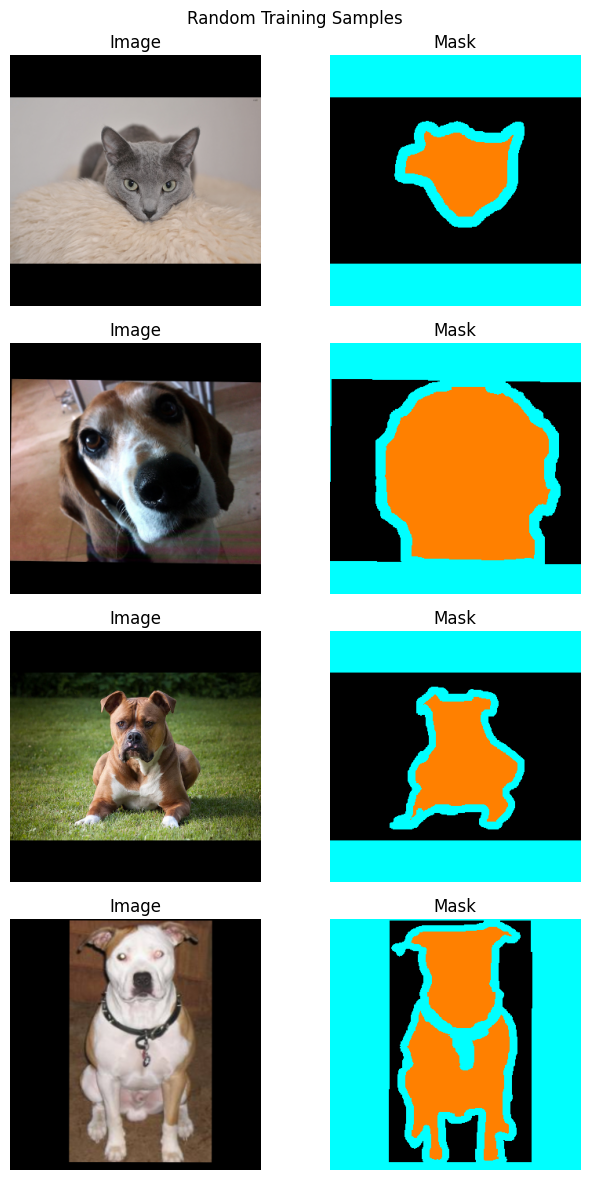

In [8]:
# ===============================================
# 8) Visualize Data
# ===============================================

def decode_mask(mask):
    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()

    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)

    for class_id, color in DISPLAY_COLORS.items():
        rgb[mask == class_id] = color

    return rgb

def denormalize_image(img):
    if torch.is_tensor(img):
        img = img.detach().cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    return (img * std + mean).clamp(0, 1)

def show_samples(dataset, n=4, title="Samples"):
    n = min(n, len(dataset))
    idxs = random.sample(range(len(dataset)), n)

    fig, axs = plt.subplots(n, 2, figsize=(7, 3 * n))

    if n == 1:
        axs = np.expand_dims(axs, axis=0)

    for row, idx in enumerate(idxs):
        img, mask = dataset[idx]

        axs[row, 0].imshow(denormalize_image(img).permute(1, 2, 0).numpy())
        axs[row, 0].set_title("Image")
        axs[row, 0].axis("off")

        axs[row, 1].imshow(decode_mask(mask))
        axs[row, 1].set_title("Mask")
        axs[row, 1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=4, title="Random Training Samples")

In [9]:
# ===============================================
# 9) Metrics
# ===============================================

def compute_batch_stats(preds, targets, num_classes, ignore_index=IGNORE_INDEX):
    preds = preds.detach().cpu()
    targets = targets.detach().cpu()

    valid_mask = targets != ignore_index

    correct = (preds[valid_mask] == targets[valid_mask]).sum().item()
    total = valid_mask.sum().item()

    intersections = np.zeros(num_classes, dtype=np.float64)
    unions = np.zeros(num_classes, dtype=np.float64)

    for cls in range(num_classes):
        pred_cls = (preds == cls) & valid_mask
        target_cls = (targets == cls) & valid_mask

        intersections[cls] = (pred_cls & target_cls).sum().item()
        unions[cls] = (pred_cls | target_cls).sum().item()

    return correct, total, intersections, unions

def compute_iou(intersections, unions):
    ious = np.full_like(intersections, fill_value=np.nan, dtype=np.float64)

    valid = unions > 0
    ious[valid] = intersections[valid] / unions[valid]

    miou = float(np.nanmean(ious)) if np.any(valid) else 0.0

    return miou, ious

In [10]:
# ===============================================
# 10) Prediction Thresholding and Post-processing
# ===============================================

def logits_to_preds(logits, threshold=None):
    if threshold is None:
        return logits.argmax(dim=1)

    probs = torch.softmax(logits, dim=1)
    pet_probs = probs[:, 1, :, :]
    preds = (pet_probs >= threshold).long()

    return preds

def postprocess_single_mask(
    pred_mask,
    ignore_mask=None,
    keep_largest=True,
    remove_small=True,
    min_area_pixels=100,
    use_morph_opening=False,
    morph_kernel_size=3
):
    if torch.is_tensor(pred_mask):
        pred_np = pred_mask.detach().cpu().numpy().astype(np.uint8)
    else:
        pred_np = pred_mask.astype(np.uint8)

    pet_mask = (pred_np == 1).astype(np.uint8)

    if ignore_mask is not None:
        if torch.is_tensor(ignore_mask):
            ignore_np = ignore_mask.detach().cpu().numpy().astype(bool)
        else:
            ignore_np = ignore_mask.astype(bool)

        pet_mask[ignore_np] = 0
    else:
        ignore_np = None

    if use_morph_opening:
        kernel = np.ones((morph_kernel_size, morph_kernel_size), dtype=np.uint8)
        pet_mask = cv2.morphologyEx(pet_mask, cv2.MORPH_OPEN, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        pet_mask,
        connectivity=8
    )

    clean_pet = np.zeros_like(pet_mask, dtype=np.uint8)

    if num_labels > 1:
        component_ids = np.arange(1, num_labels)
        component_areas = stats[1:, cv2.CC_STAT_AREA]

        if keep_largest:
            largest_local_idx = np.argmax(component_areas)
            largest_component_id = component_ids[largest_local_idx]
            largest_area = component_areas[largest_local_idx]

            if (not remove_small) or (largest_area >= min_area_pixels):
                clean_pet[labels == largest_component_id] = 1

        else:
            for component_id, area in zip(component_ids, component_areas):
                if (not remove_small) or (area >= min_area_pixels):
                    clean_pet[labels == component_id] = 1

    output = clean_pet.astype(np.uint8)

    if ignore_np is not None:
        output[ignore_np] = IGNORE_INDEX

    return torch.from_numpy(output).long()

def postprocess_batch_preds(
    preds,
    targets=None,
    keep_largest=KEEP_LARGEST_COMPONENT,
    remove_small=REMOVE_SMALL_COMPONENTS,
    min_area_pixels=MIN_COMPONENT_AREA_PIXELS,
    use_morph_opening=USE_MORPH_OPENING,
    morph_kernel_size=MORPH_KERNEL_SIZE
):
    processed = []

    for i in range(preds.shape[0]):
        ignore_mask = None

        if targets is not None:
            ignore_mask = targets[i] == IGNORE_INDEX

        clean_mask = postprocess_single_mask(
            pred_mask=preds[i],
            ignore_mask=ignore_mask,
            keep_largest=keep_largest,
            remove_small=remove_small,
            min_area_pixels=min_area_pixels,
            use_morph_opening=use_morph_opening,
            morph_kernel_size=morph_kernel_size
        )

        processed.append(clean_mask)

    return torch.stack(processed, dim=0)

In [11]:
# ===============================================
# 11) Define Model
# ===============================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, num_classes, base_channels=32):
        super().__init__()

        c1 = base_channels
        c2 = base_channels * 2
        c3 = base_channels * 4
        c4 = base_channels * 8
        c5 = base_channels * 16

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc1 = DoubleConv(3, c1)
        self.enc2 = DoubleConv(c1, c2)
        self.enc3 = DoubleConv(c2, c3)
        self.enc4 = DoubleConv(c3, c4)

        self.bottleneck = DoubleConv(c4, c5)

        self.up4 = nn.ConvTranspose2d(c5, c4, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(c4 + c4, c4)

        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c3 + c3, c3)

        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c2 + c2, c2)

        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c1 + c1, c1)

        self.classifier = nn.Conv2d(c1, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.classifier(d1)

In [12]:
# ===============================================
# 12) Training Setup
# ===============================================

class LeakageAwareLoss(nn.Module):
    def __init__(
        self,
        num_classes=2,
        ignore_index=255,
        ce_weight=1.0,
        focal_tversky_weight=1.0,
        background_ce_weight=1.10,
        pet_ce_weight=1.00,
        tversky_alpha=0.65,
        tversky_beta=0.35,
        tversky_gamma=1.25,
        smooth=1e-6
    ):
        super().__init__()

        self.num_classes = num_classes
        self.ignore_index = ignore_index

        self.ce_weight = ce_weight
        self.focal_tversky_weight = focal_tversky_weight

        self.tversky_alpha = tversky_alpha
        self.tversky_beta = tversky_beta
        self.tversky_gamma = tversky_gamma

        self.smooth = smooth

        class_weights = torch.tensor(
            [background_ce_weight, pet_ce_weight],
            dtype=torch.float32
        )

        self.register_buffer("class_weights", class_weights)

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.class_weights,
            ignore_index=self.ignore_index
        )

        probs = torch.softmax(logits, dim=1)
        pet_probs = probs[:, 1, :, :]

        valid_mask = targets != self.ignore_index
        valid_mask_float = valid_mask.float()

        target_pet = (targets == 1).float()

        pet_probs = pet_probs * valid_mask_float
        target_pet = target_pet * valid_mask_float

        true_positive = (pet_probs * target_pet).sum(dim=(1, 2))

        false_positive = (
            pet_probs * (1.0 - target_pet) * valid_mask_float
        ).sum(dim=(1, 2))

        false_negative = (
            (1.0 - pet_probs) * target_pet
        ).sum(dim=(1, 2))

        tversky_index = (
            true_positive + self.smooth
        ) / (
            true_positive
            + self.tversky_alpha * false_positive
            + self.tversky_beta * false_negative
            + self.smooth
        )

        focal_tversky_loss = torch.pow(
            1.0 - tversky_index,
            self.tversky_gamma
        ).mean()

        total_loss = (
            self.ce_weight * ce_loss
            + self.focal_tversky_weight * focal_tversky_loss
        )

        return total_loss

model = UNet(
    num_classes=NUM_CLASSES,
    base_channels=32
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

criterion = LeakageAwareLoss(
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    ce_weight=CE_LOSS_WEIGHT,
    focal_tversky_weight=FOCAL_TVERSKY_WEIGHT,
    background_ce_weight=BACKGROUND_CE_WEIGHT,
    pet_ce_weight=PET_CE_WEIGHT,
    tversky_alpha=TVERSKY_ALPHA,
    tversky_beta=TVERSKY_BETA,
    tversky_gamma=TVERSKY_GAMMA
).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

use_amp = torch.cuda.is_available()

if use_amp:
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=True)
    except Exception:
        scaler = torch.cuda.amp.GradScaler(enabled=True)
else:
    scaler = torch.cuda.amp.GradScaler(enabled=False)

def autocast_context():
    if use_amp:
        try:
            return torch.amp.autocast(device_type="cuda", enabled=True)
        except Exception:
            return torch.cuda.amp.autocast(enabled=True)
    else:
        return nullcontext()

print("AMP enabled:", use_amp)

Total parameters    : 7,763,074
Trainable parameters: 7,763,074
AMP enabled: True


In [13]:
# ===============================================
# 13) Training and Evaluation Functions
# ===============================================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    total_valid_pixels = 0

    correct_pixels = 0
    total_pixels = 0

    intersections = np.zeros(NUM_CLASSES, dtype=np.float64)
    unions = np.zeros(NUM_CLASSES, dtype=np.float64)

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            preds = logits_to_preds(
                outputs,
                threshold=DEFAULT_PRED_THRESHOLD
            )

            valid_pixels = (masks != IGNORE_INDEX).sum().item()

            total_loss += loss.item() * valid_pixels
            total_valid_pixels += valid_pixels

            correct, total, inter, union = compute_batch_stats(
                preds,
                masks,
                NUM_CLASSES,
                IGNORE_INDEX
            )

            correct_pixels += correct
            total_pixels += total
            intersections += inter
            unions += union

    avg_loss = total_loss / total_valid_pixels if total_valid_pixels > 0 else 0.0
    pixel_acc = correct_pixels / total_pixels if total_pixels > 0 else 0.0
    miou, ious = compute_iou(intersections, unions)

    return avg_loss, pixel_acc, miou, ious

def evaluate(
    model,
    loader,
    criterion,
    desc="Eval",
    threshold=DEFAULT_PRED_THRESHOLD,
    apply_postprocess=False
):
    model.eval()

    total_loss = 0.0
    total_valid_pixels = 0

    correct_pixels = 0
    total_pixels = 0

    intersections = np.zeros(NUM_CLASSES, dtype=np.float64)
    unions = np.zeros(NUM_CLASSES, dtype=np.float64)

    with torch.no_grad():
        for images, masks in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with autocast_context():
                outputs = model(images)
                loss = criterion(outputs, masks)

            preds = logits_to_preds(
                outputs,
                threshold=threshold
            )

            if apply_postprocess:
                preds = postprocess_batch_preds(
                    preds=preds,
                    targets=masks
                )

            valid_pixels = (masks != IGNORE_INDEX).sum().item()

            total_loss += loss.item() * valid_pixels
            total_valid_pixels += valid_pixels

            correct, total, inter, union = compute_batch_stats(
                preds,
                masks,
                NUM_CLASSES,
                IGNORE_INDEX
            )

            correct_pixels += correct
            total_pixels += total
            intersections += inter
            unions += union

    avg_loss = total_loss / total_valid_pixels if total_valid_pixels > 0 else 0.0
    pixel_acc = correct_pixels / total_pixels if total_pixels > 0 else 0.0
    miou, ious = compute_iou(intersections, unions)

    return avg_loss, pixel_acc, miou, ious

In [14]:
# ===============================================
# 14) Checkpoint Setup
# ===============================================

history = {
    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_miou": [],
    "val_miou": [],

    "train_bg_iou": [],
    "val_bg_iou": [],

    "train_pet_iou": [],
    "val_pet_iou": [],

    "lr": []
}

best_val_miou = -float("inf")
best_epoch = 0
epochs_no_improve = 0
start_epoch = 0

if RESUME_TRAINING and os.path.exists(CHECKPOINT_PATH):
    print("Checkpoint found. Loading...")

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

    try:
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        scheduler.load_state_dict(checkpoint["scheduler_state"])

        if "scaler_state" in checkpoint:
            scaler.load_state_dict(checkpoint["scaler_state"])

        history = checkpoint["history"]
        best_val_miou = checkpoint["best_val_miou"]
        best_epoch = checkpoint.get("best_epoch", 0)
        epochs_no_improve = checkpoint.get("epochs_no_improve", 0)
        start_epoch = checkpoint["epoch"]

        print(f"Resuming from epoch {start_epoch + 1}")
        print(f"Best Val mIoU so far: {best_val_miou:.4f}")
        print(f"Best epoch so far   : {best_epoch}")

    except Exception as e:
        print("Could not load checkpoint. Starting from scratch.")
        print("Reason:", e)

        history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": [],
            "train_miou": [],
            "val_miou": [],
            "train_bg_iou": [],
            "val_bg_iou": [],
            "train_pet_iou": [],
            "val_pet_iou": [],
            "lr": []
        }

        best_val_miou = -float("inf")
        best_epoch = 0
        epochs_no_improve = 0
        start_epoch = 0
else:
    print("Starting from scratch.")

Starting from scratch.


In [15]:
# ===============================================
# 15) Train Model
# ===============================================

print("\nStarting Training...")

for epoch in range(start_epoch, EPOCHS):
    train_loss, train_acc, train_miou, train_ious = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc, val_miou, val_ious = evaluate(
        model,
        val_loader,
        criterion,
        desc="Val",
        threshold=DEFAULT_PRED_THRESHOLD,
        apply_postprocess=USE_POSTPROCESS
    )

    scheduler.step(val_miou)

    current_lr = optimizer.param_groups[0]["lr"]

    train_bg_iou = train_ious[0] if not np.isnan(train_ious[0]) else 0.0
    train_pet_iou = train_ious[1] if not np.isnan(train_ious[1]) else 0.0

    val_bg_iou = val_ious[0] if not np.isnan(val_ious[0]) else 0.0
    val_pet_iou = val_ious[1] if not np.isnan(val_ious[1]) else 0.0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_miou"].append(train_miou)
    history["val_miou"].append(val_miou)

    history["train_bg_iou"].append(train_bg_iou)
    history["val_bg_iou"].append(val_bg_iou)

    history["train_pet_iou"].append(train_pet_iou)
    history["val_pet_iou"].append(val_pet_iou)

    history["lr"].append(current_lr)

    torch.save(model.state_dict(), LAST_MODEL_PATH)

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_epoch = epoch + 1
        epochs_no_improve = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)
        best_tag = " | best"
    else:
        epochs_no_improve += 1
        best_tag = ""

    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "history": history,
        "best_val_miou": best_val_miou,
        "best_epoch": best_epoch,
        "epochs_no_improve": epochs_no_improve,
    }, CHECKPOINT_PATH)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
        f"Train mIoU: {train_miou:.4f} | Val mIoU: {val_miou:.4f} | "
        f"Val Pet IoU: {val_pet_iou:.4f} | "
        f"LR: {current_lr:.2e}{best_tag}"
    )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after epoch {epoch + 1}.")
        break

print("\nTraining finished.")
print(f"Best epoch   : {best_epoch}")
print(f"Best Val mIoU: {best_val_miou:.4f}")
print(f"Best model saved to: {BEST_MODEL_PATH}")
print(f"Last model saved to: {LAST_MODEL_PATH}")
print(f"Checkpoint saved to : {CHECKPOINT_PATH}")


Starting Training...


Epoch 01/18 | Train Loss: 0.7467 | Val Loss: 0.6927 | Train Acc: 0.8047 | Val Acc: 0.8706 | Train mIoU: 0.6354 | Val mIoU: 0.7371 | Val Pet IoU: 0.6428 | LR: 1.00e-04 | best


Epoch 02/18 | Train Loss: 0.5958 | Val Loss: 0.5388 | Train Acc: 0.8456 | Val Acc: 0.8781 | Train mIoU: 0.7020 | Val mIoU: 0.7432 | Val Pet IoU: 0.6426 | LR: 1.00e-04 | best


Epoch 03/18 | Train Loss: 0.5123 | Val Loss: 0.4892 | Train Acc: 0.8674 | Val Acc: 0.9091 | Train mIoU: 0.7394 | Val mIoU: 0.8066 | Val Pet IoU: 0.7348 | LR: 1.00e-04 | best


Epoch 04/18 | Train Loss: 0.4506 | Val Loss: 0.3831 | Train Acc: 0.8841 | Val Acc: 0.9157 | Train mIoU: 0.7695 | Val mIoU: 0.8188 | Val Pet IoU: 0.7505 | LR: 1.00e-04 | best


...

Epoch 14/18 | Train Loss: 0.1833 | Val Loss: 0.2002 | Train Acc: 0.9536 | Val Acc: 0.9649 | Train mIoU: 0.9020 | Val mIoU: 0.9225 | Val Pet IoU: 0.8953 | LR: 5.00e-05 | best


Epoch 15/18 | Train Loss: 0.1749 | Val Loss: 0.1964 | Train Acc: 0.9559 | Val Acc: 0.9523 | Train mIoU: 0.9066 | Val mIoU: 0.8955 | Val Pet IoU: 0.8580 | LR: 5.00e-05


Epoch 16/18 | Train Loss: 0.1692 | Val Loss: 0.1767 | Train Acc: 0.9571 | Val Acc: 0.9585 | Train mIoU: 0.9090 | Val mIoU: 0.9088 | Val Pet IoU: 0.8762 | LR: 5.00e-05


Epoch 17/18 | Train Loss: 0.1640 | Val Loss: 0.2029 | Train Acc: 0.9585 | Val Acc: 0.9517 | Train mIoU: 0.9119 | Val mIoU: 0.8942 | Val Pet IoU: 0.8561 | LR: 2.50e-05


Epoch 18/18 | Train Loss: 0.1362 | Val Loss: 0.1686 | Train Acc: 0.9657 | Val Acc: 0.9696 | Train mIoU: 0.9266 | Val mIoU: 0.9329 | Val Pet IoU: 0.9095 | LR: 2.50e-05 | best

Training finished.
Best epoch   : 18
Best Val mIoU: 0.9329
Best model saved to: /content/unet_pet_best_miou.pth
Last model saved to: /content/unet_pet_last_epoch.pth
Checkpoint saved to : /content/unet_pet_checkpoint.pth


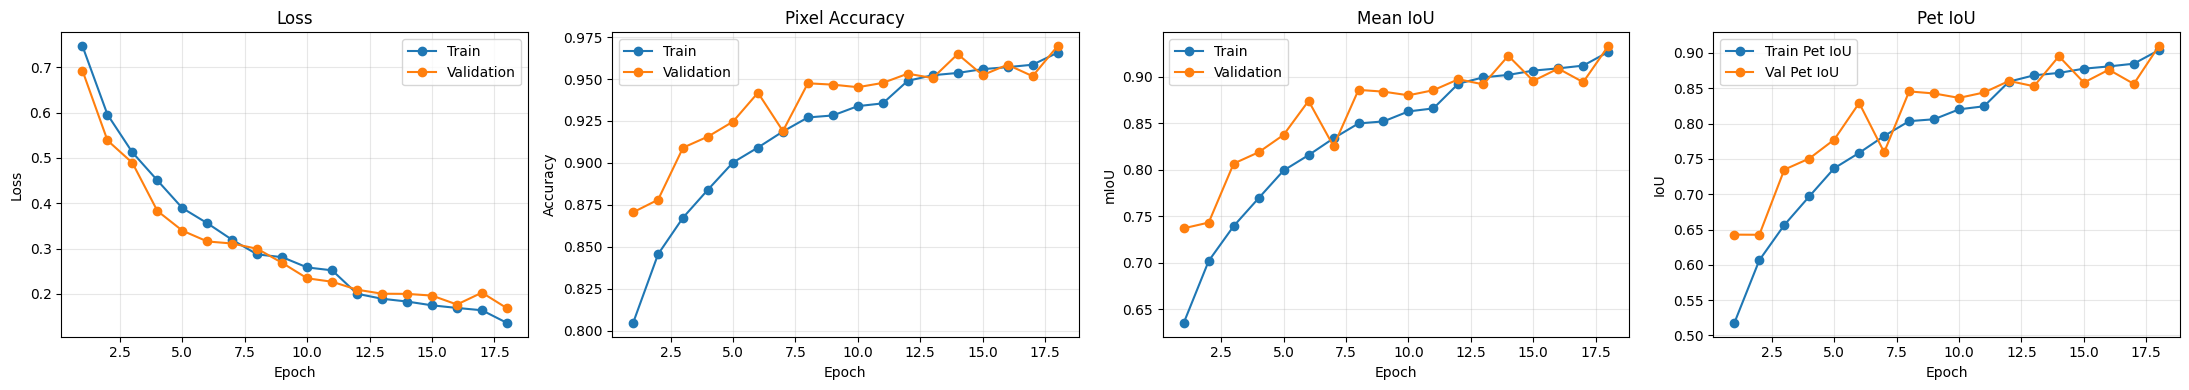

Training curves saved to: /content/training_curves.png


In [16]:
# ===============================================
# 16) Visualize Training Results
# ===============================================

epochs_ran = len(history["train_loss"])
x_axis = np.arange(1, epochs_ran + 1)

fig, axs = plt.subplots(1, 4, figsize=(22, 4))

axs[0].plot(x_axis, history["train_loss"], "-o", label="Train")
axs[0].plot(x_axis, history["val_loss"], "-o", label="Validation")
axs[0].set_title("Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(x_axis, history["train_acc"], "-o", label="Train")
axs[1].plot(x_axis, history["val_acc"], "-o", label="Validation")
axs[1].set_title("Pixel Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[2].plot(x_axis, history["train_miou"], "-o", label="Train")
axs[2].plot(x_axis, history["val_miou"], "-o", label="Validation")
axs[2].set_title("Mean IoU")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("mIoU")
axs[2].legend()
axs[2].grid(alpha=0.3)

axs[3].plot(x_axis, history["train_pet_iou"], "-o", label="Train Pet IoU")
axs[3].plot(x_axis, history["val_pet_iou"], "-o", label="Val Pet IoU")
axs[3].set_title("Pet IoU")
axs[3].set_xlabel("Epoch")
axs[3].set_ylabel("IoU")
axs[3].legend()
axs[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(TRAINING_CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Training curves saved to: {TRAINING_CURVES_PATH}")

In [17]:
# ===============================================
# 17) Threshold Tuning
# ===============================================

def tune_prediction_threshold(
    model,
    loader,
    criterion,
    candidates,
    apply_postprocess=True
):
    results = []

    print("\nTuning prediction threshold on validation set...")
    print("-" * 70)

    for threshold in candidates:
        val_loss, val_acc, val_miou, val_ious = evaluate(
            model,
            loader,
            criterion,
            desc=f"Threshold {threshold:.2f}",
            threshold=threshold,
            apply_postprocess=apply_postprocess
        )

        bg_iou = val_ious[0] if not np.isnan(val_ious[0]) else 0.0
        pet_iou = val_ious[1] if not np.isnan(val_ious[1]) else 0.0

        result = {
            "threshold": threshold,
            "loss": val_loss,
            "acc": val_acc,
            "miou": val_miou,
            "bg_iou": bg_iou,
            "pet_iou": pet_iou
        }

        results.append(result)

        print(
            f"Threshold: {threshold:.2f} | "
            f"Val mIoU: {val_miou:.4f} | "
            f"BG IoU: {bg_iou:.4f} | "
            f"Pet IoU: {pet_iou:.4f} | "
            f"Acc: {val_acc:.4f}"
        )

    best_miou = max(item["miou"] for item in results)

    close_results = [
        item for item in results
        if best_miou - item["miou"] <= 0.002
    ]

    best_result = max(
        close_results,
        key=lambda item: item["threshold"]
    )

    print("-" * 70)
    print(
        f"Selected threshold: {best_result['threshold']:.2f} | "
        f"Val mIoU: {best_result['miou']:.4f} | "
        f"BG IoU: {best_result['bg_iou']:.4f} | "
        f"Pet IoU: {best_result['pet_iou']:.4f}"
    )
    print("-" * 70)

    return best_result["threshold"], results

In [18]:
# ===============================================
# 18) Evaluate Model
# ===============================================

print("\nLoading best model for final test evaluation...")

try:
    state_dict = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(BEST_MODEL_PATH, map_location=device)

model.load_state_dict(state_dict)
model.eval()

BEST_PRED_THRESHOLD, threshold_results = tune_prediction_threshold(
    model=model,
    loader=val_loader,
    criterion=criterion,
    candidates=THRESHOLD_CANDIDATES,
    apply_postprocess=USE_POSTPROCESS
)

np.save(
    THRESHOLD_RESULTS_PATH,
    np.array(threshold_results, dtype=object),
    allow_pickle=True
)

print(f"Threshold results saved to: {THRESHOLD_RESULTS_PATH}")

test_loss, test_acc, test_miou, test_ious = evaluate(
    model,
    test_loader,
    criterion,
    desc="Test",
    threshold=BEST_PRED_THRESHOLD,
    apply_postprocess=USE_POSTPROCESS
)

test_bg_iou = test_ious[0] if not np.isnan(test_ious[0]) else 0.0
test_pet_iou = test_ious[1] if not np.isnan(test_ious[1]) else 0.0

print("=" * 55)
print("Final Test Evaluation Using Best Model")
print("=" * 55)
print(f"Selected Threshold  : {BEST_PRED_THRESHOLD:.2f}")
print(f"Post-processing     : {USE_POSTPROCESS}")
print(f"Test Loss           : {test_loss:.4f}")
print(f"Test Pixel Accuracy : {test_acc:.4f}")
print(f"Test Mean IoU       : {test_miou:.4f}")
print(f"Test Background IoU : {test_bg_iou:.4f}")
print(f"Test Pet IoU        : {test_pet_iou:.4f}")
print("=" * 55)


Loading best model for final test evaluation...

Tuning prediction threshold on validation set...
----------------------------------------------------------------------


Threshold: 0.50 | Val mIoU: 0.9352 | BG IoU: 0.9575 | Pet IoU: 0.9128 | Acc: 0.9706


Threshold: 0.55 | Val mIoU: 0.9328 | BG IoU: 0.9561 | Pet IoU: 0.9096 | Acc: 0.9695


Threshold: 0.60 | Val mIoU: 0.9329 | BG IoU: 0.9562 | Pet IoU: 0.9095 | Acc: 0.9696


Threshold: 0.65 | Val mIoU: 0.9315 | BG IoU: 0.9554 | Pet IoU: 0.9077 | Acc: 0.9690


Threshold: 0.70 | Val mIoU: 0.9285 | BG IoU: 0.9535 | Pet IoU: 0.9034 | Acc: 0.9676


Threshold: 0.75 | Val mIoU: 0.9239 | BG IoU: 0.9506 | Pet IoU: 0.8971 | Acc: 0.9655
----------------------------------------------------------------------
Selected threshold: 0.50 | Val mIoU: 0.9352 | BG IoU: 0.9575 | Pet IoU: 0.9128
----------------------------------------------------------------------
Threshold results saved to: /content/threshold_results.npy


Final Test Evaluation Using Best Model
Selected Threshold  : 0.50
Post-processing     : True
Test Loss           : 0.1812
Test Pixel Accuracy : 0.9667
Test Mean IoU       : 0.9280
Test Background IoU : 0.9513
Test Pet IoU        : 0.9047


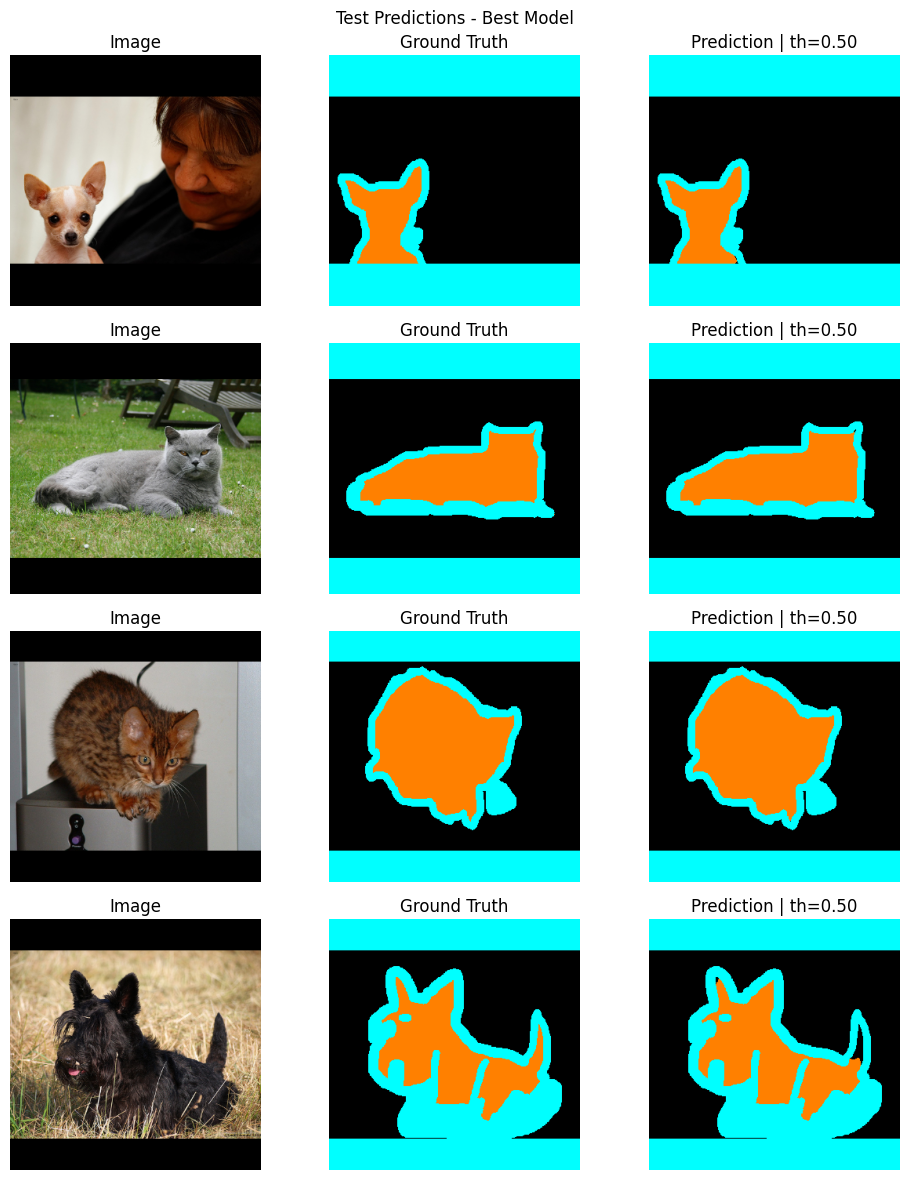

Prediction samples saved to: /content/test_predictions.png


In [19]:
# ===============================================
# 19) Visualize Predictions
# ===============================================

def show_predictions(
    dataset,
    model,
    n=4,
    title="Predictions",
    save_path=None,
    threshold=DEFAULT_PRED_THRESHOLD,
    apply_postprocess=True
):
    n = min(n, len(dataset))
    idxs = random.sample(range(len(dataset)), n)

    fig, axs = plt.subplots(n, 3, figsize=(10, 3 * n))

    if n == 1:
        axs = np.expand_dims(axs, axis=0)

    model.eval()

    for row, idx in enumerate(idxs):
        img, gt_mask = dataset[idx]

        with torch.no_grad():
            logits = model(img.unsqueeze(0).to(device))

            pred_mask = logits_to_preds(
                logits,
                threshold=threshold
            )[0].cpu()

        if apply_postprocess:
            pred_mask = postprocess_single_mask(
                pred_mask=pred_mask,
                ignore_mask=(gt_mask == IGNORE_INDEX),
                keep_largest=KEEP_LARGEST_COMPONENT,
                remove_small=REMOVE_SMALL_COMPONENTS,
                min_area_pixels=MIN_COMPONENT_AREA_PIXELS,
                use_morph_opening=USE_MORPH_OPENING,
                morph_kernel_size=MORPH_KERNEL_SIZE
            )

        pred_mask[gt_mask == IGNORE_INDEX] = IGNORE_INDEX

        axs[row, 0].imshow(
            denormalize_image(img).permute(1, 2, 0).numpy()
        )
        axs[row, 0].set_title("Image")
        axs[row, 0].axis("off")

        axs[row, 1].imshow(decode_mask(gt_mask))
        axs[row, 1].set_title("Ground Truth")
        axs[row, 1].axis("off")

        axs[row, 2].imshow(decode_mask(pred_mask))
        axs[row, 2].set_title(f"Prediction | th={threshold:.2f}")
        axs[row, 2].axis("off")

    fig.suptitle(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

show_predictions(
    dataset=test_ds,
    model=model,
    n=4,
    title="Test Predictions - Best Model",
    save_path=PREDICTIONS_PATH,
    threshold=BEST_PRED_THRESHOLD,
    apply_postprocess=USE_POSTPROCESS
)

print(f"Prediction samples saved to: {PREDICTIONS_PATH}")

In [20]:
# ===============================================
# 20) Final Summary
# ===============================================

print("\nFinal Summary")
print("=" * 55)
print(f"Best model path       : {BEST_MODEL_PATH}")
print(f"Last epoch model path : {LAST_MODEL_PATH}")
print(f"Checkpoint path       : {CHECKPOINT_PATH}")
print(f"Split path            : {SPLIT_PATH}")
print(f"Training curves path  : {TRAINING_CURVES_PATH}")
print(f"Predictions path      : {PREDICTIONS_PATH}")
print(f"Threshold result path : {THRESHOLD_RESULTS_PATH}")
print("-" * 55)
print(f"Best epoch            : {best_epoch}")
print(f"Best Val mIoU         : {best_val_miou:.4f}")
print(f"Selected threshold    : {BEST_PRED_THRESHOLD:.2f}")
print(f"Post-processing       : {USE_POSTPROCESS}")
print(f"Keep largest component: {KEEP_LARGEST_COMPONENT}")
print(f"Min component pixels  : {MIN_COMPONENT_AREA_PIXELS}")
print(f"Test Loss             : {test_loss:.4f}")
print(f"Test Pixel Accuracy   : {test_acc:.4f}")
print(f"Test Mean IoU         : {test_miou:.4f}")
print(f"Test Background IoU   : {test_bg_iou:.4f}")
print(f"Test Pet IoU          : {test_pet_iou:.4f}")
print("=" * 55)
print("Pipeline finished.")


Final Summary
Best model path       : /content/unet_pet_best_miou.pth
Last epoch model path : /content/unet_pet_last_epoch.pth
Checkpoint path       : /content/unet_pet_checkpoint.pth
Split path            : /content/split_indices.npz
Training curves path  : /content/training_curves.png
Predictions path      : /content/test_predictions.png
Threshold result path : /content/threshold_results.npy
-------------------------------------------------------
Best epoch            : 18
Best Val mIoU         : 0.9329
Selected threshold    : 0.50
Post-processing       : True
Keep largest component: True
Min component pixels  : 102
Test Loss             : 0.1812
Test Pixel Accuracy   : 0.9667
Test Mean IoU         : 0.9280
Test Background IoU   : 0.9513
Test Pet IoU          : 0.9047
Pipeline finished.
